## 3.2 Linear Least Squares Normal Equations

In [2]:
using Random
using CairoMakie
using Distributions

Linear least squares regression is a method of fitting a function with linear coefficients to some data points.  Examples of these functions are

$y=a_0+a_1x+a_2x^2+a_3x^3+...$

$y=a_1+a_2\sin(x)+a_3e^{-x^2}$

So what we want to find are $a_0, a_1, a_2,....$ that best fits the data points. Note that the function themselves are nonlinear but the functions are linear with respect to  the coefficients. $a_0, a_1, a_2,....$.  The  linear least squares regression method described in this notebook will apply as long as the functions are linear with respect to the coefficients.

In the last notebook, we model the data using the linear function

$y=a_0+a_1x$

and we used the method of gradient descent to try and find optimum values of $a_0$ and $a_1$. In this notebook we will try and fit data set using a more complex model

$y=a_0+a_1x+a_2x^2$

We can use gradient descent to find $a_0$, $a_1$ and $a_2$ but I will show you a different method of finding $a_0$, $a_1$ and $a_2$ using "Normal Equations"

I will illustrate the "Normal Equations" method with an example where we have $N$ data pairs $(x_i,y_i)$. We will first generate fictitious data from the function 

$
y=0.5+x+3x^2 +\epsilon
$

where $x \in [-1,1]$.  $\epsilon$ is some small amount of noise.  

* For most problems, you do not know how the function looks like.  
* But here, I am going to generate data from a known function  and then I will find a model that fits the data. 
* The advantage of having data from a known function is that I can tell if my model is correct  and check if my process is right.

* For real problems, your data would come from your experiments, simulations and be stored in a spreadsheet.

Generating the data

In [3]:
N_SAMPLES=50 #50 data points
rng=Xoshiro(1) #my random number genrator

x_samples=rand(rng,Uniform(-1,1),N_SAMPLES) #generate random values of x between -1 and 1
y_noise=rand(rng,Normal(0.0,0.1),N_SAMPLES) #generate some noise, normal distribution with standard deviation of 0.1
y_samples=3*x_samples.^2.0.+(x_samples).+0.5.+y_noise; #y=3x^2+x+0.5+epsilon

Let's plot the data and see how it looks like

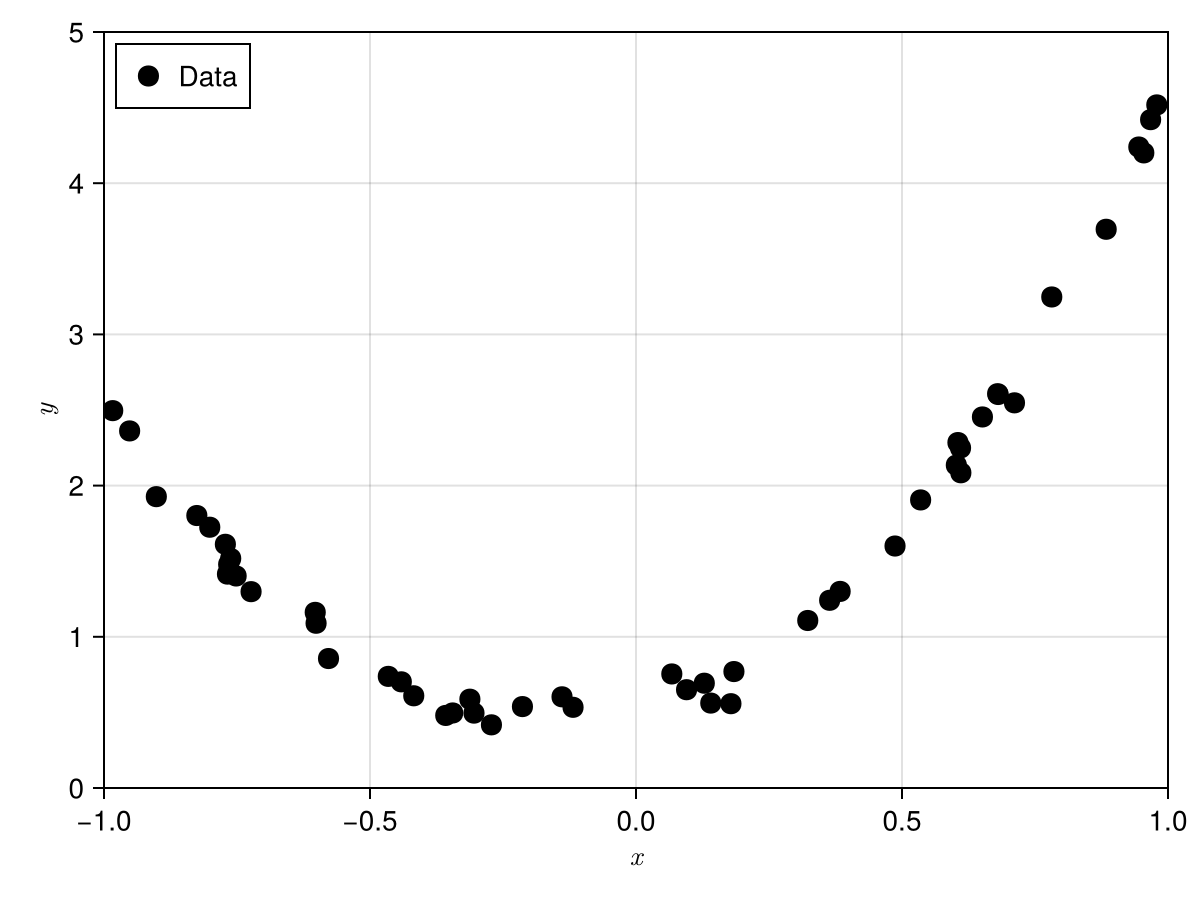

CairoMakie.Screen{IMAGE}


In [4]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",limits=(-1,1,0,5))
scatter!(ax,x_samples,y_samples;label="Data",color=:black,markersize=15)
axislegend(ax;position = :lt)
display(fig)

Let's try to fit the function 

$y = a_0  + a_1 x + a_2x^2$
to these data points.  So we want to find $a_0$,  $a_1$  and $a_2$. 

Recall that our original fictious data set was generated using the function 

$y=3x^2+x+0.5$

So if the theory and code below is correct, we should get 


$a_0\approx 0.5$

$a_1\approx 1.0$

$a_2\approx 3.0$



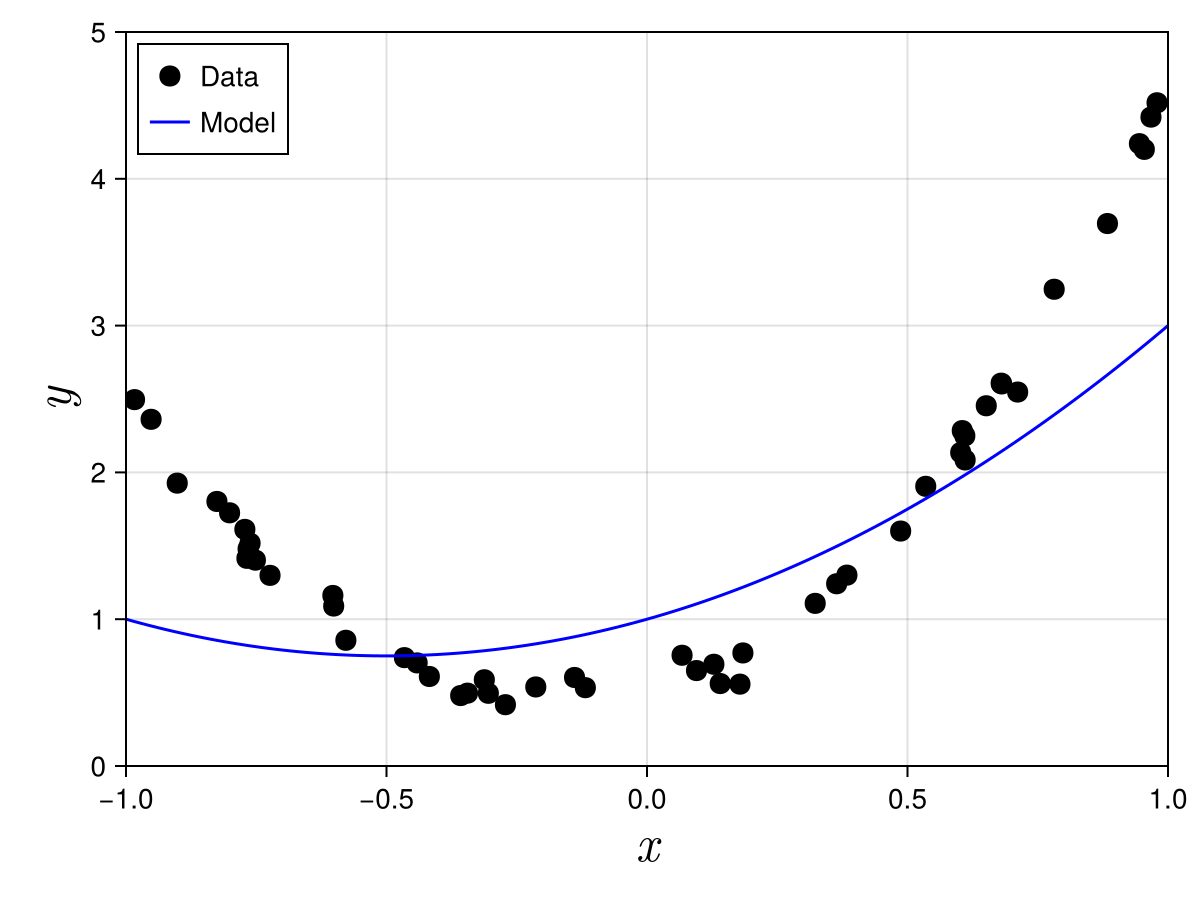

CairoMakie.Screen{IMAGE}


In [5]:
a=[1.0,1.0,1.0] #initial assumptions of the values of  a0, a1, a2.  Remember that the indexing in Julia
                # starts from 1, not 0. So a[1] is a0, a[2] is a1 and a[3] is a2.
xplot=-1:0.01:1
yplot=a[1].+a[2]*xplot.+a[3]*xplot.^2.0

fig = Figure()
ax = Axis(fig[1, 1], 
    xlabel = L"x", 
    ylabel = L"y",
    xlabelsize=25,
    ylabelsize=25,
    limits=(-1,1,0,5))
scatter!(ax,x_samples,y_samples;label="Data",color=:black,markersize=15)
lines!(ax,xplot,yplot;label="Model",color=:blue)
axislegend(ax;position = :lt)
save("../figures/03p01LinearLeastSquaresRegression01.png",fig)
display(fig)

This is not a good fit!  We can keep trying different values of $a_i$'s but this is not very efficient.  Linear least squares is a systematic way of finding this fit.

The overall idea is to define an error and then try to minimise the error between the actual data and the polynomial fit.

The local error between the actual data and the polynomial is defined as

$  e_i  = \underbrace{y_i}_{\rm{actual\, value}}  - \underbrace{\left( {a_0  + a_1 x_i  + a_2 x_i^2  } \right)}_{\rm{predicted\, value}}$



Define an overall  error, $S$,  as the sum of squares of the local error

$S = \sum\limits_{i = 1}^{N} {e_i^2 }  = \sum\limits_{i = 1}^{N} {\left( {y_i  - a_0  - a_1 x_i  - a_2 x_i^2} \right)} ^2$

$
\begin{align}
S =& \left( {y_1  - a_0  - a_1 x_1  - a_2 x_1^2} \right) ^2\\
+&\left( {y_2  - a_0  - a_1 x_2  - a_2 x_2^2} \right) ^2\\
+&\left( {y_3  - a_0  - a_1 x_3  - a_2 x_3^2} \right) ^2\\
+&.....\\
+&\left( {y_N  - a_0  - a_1 x_N  - a_2 x_N^2} \right) ^2
\end{align}
$

We want to find $a_0$, $a_1$ and $a_2$ such that we minimise $S$.  So we need to differentiate $S$ with respect to $a_0$, $a_1$ and $a_2$ and set the derivatives to zero  

$
\begin{align}
\frac{\partial S}{\partial a_0} =& 2\left( {y_1  - a_0  - a_1 x_1  - a_2 x_1^2} \right) (-1)\\
+&2\left( {y_2  - a_0  - a_1 x_2  - a_2 x_2^2} \right)(-1)\\
+&2\left( {y_3  - a_0  - a_1 x_3  - a_2 x_3^2} \right)(-1)\\
+&.....\\
+&2\left( {y_N  - a_0  - a_1 x_N  - a_2 x_N^2} \right)(-1)=0
\end{align}
$

$
\begin{align}
 \sum_{i=1}^{N}y_i -\sum_{i=1}^{N}a_0-a_1\sum_{i=1}^{N}x_i-a_2\sum_{i=1}^{N}x_i^2=0
\end{align}
$

$
\begin{align}
a_0 \sum_{i=1}^{N}+a_1\sum_{i=1}^{N}x_i+a_2\sum_{i=1}^{N}x_i^2=\sum_{i=1}^{N}y_i \end{align}
$

Doing the same for $\partial S/\partial a_1=0$ and $\partial S/\partial a_2=0$ gives

$
\begin{align}
 a_0\sum_{i=1}^{N}x_i+a_1\sum_{i=1}^{N}x_i^2+a_2\sum_{i=1}^{N}x_i^3= \sum_{i=1}^{N}x_iy_i
\end{align}
$

$
\begin{align}
a_0 \sum_{i=1}^{N}x_i^2+a_1\sum_{i=1}^{N}x_i^3+a_2\sum_{i=1}^{N}x_i^4= \sum_{i=1}^{N}x_i^2y_i
\end{align}
$

Writing this in Matrix form gives

$\begin{bmatrix}   N             & {\sum {x_i } }   & {\sum {x_i^2 } }  \\
{\sum {x_i } }   & {\sum {x_i^2 } } & {\sum {x_i^3 } }  \\
{\sum {x_i^2 } } & {\sum {x_i^3 } } & {\sum {x_i^4 } }  \\
\end{bmatrix}\begin{Bmatrix}
   {a_0 }  \\
   {a_1 }  \\
   {a_2 }  \\
\end{Bmatrix}=\begin{bmatrix}
   {\sum {y_i } }  \\
   {\sum {x_i y_i } }  \\
   {\sum {x_i^2 y_i } }  \\
\end{bmatrix}
$

So to get the most optimum values of $a_0$, $a_1$ and $a_2$, we need to solve the $3\times 3$ matrix above. 



Convince yourself that the matrix can be written as

$
[V]^{T}[V]\vec{a}=[V]^{T}\vec{y}
$

where

$
V=\begin{bmatrix}
1 & x_1 & x_1^2\\
1 & x_2 & x_2^2\\
1 & x_3 & x_3^2\\
1 & x_4 & x_4^2\\
1 & x_5 & x_5^2\\
\vdots\\
1 & x_N & x_N^2\\
\end{bmatrix}
$

It might be easier to write the matrix for $N=5$ to give you an insight as to what is going on

Writing this Matrix 

$\begin{bmatrix}   N             & {\sum {x_i } }   & {\sum {x_i^2 } }  \\
{\sum {x_i } }   & {\sum {x_i^2 } } & {\sum {x_i^3 } }  \\
{\sum {x_i^2 } } & {\sum {x_i^3 } } & {\sum {x_i^4 } }  \\
\end{bmatrix}\begin{Bmatrix}
   {a_0 }  \\
   {a_1 }  \\
   {a_2 }  \\
\end{Bmatrix}=\begin{bmatrix}
   {\sum {y_i } }  \\
   {\sum {x_i y_i } }  \\
   {\sum {x_i^2 y_i } }  \\
\end{bmatrix}
$


for $N=5$  gives

$
\begin{bmatrix}
1 & 1 & 1 & 1& 1\\
x_1 & x_2 & x_3 & x_4 & x_5\\
x_1^2 & x_2^2 & x_3^2 & x_4^2 & x_5^2\\
\end{bmatrix}\begin{bmatrix}
1 & x_1 & x_1^2\\
1 & x_2 & x_2^2\\
1 & x_3 & x_3^2\\
1 & x_4 & x_4^2\\
1 & x_5 & x_5^2\\
\end{bmatrix}\begin{Bmatrix}
   {a_0 }  \\
   {a_1 }  \\
   {a_2 }  \\
\end{Bmatrix}=\begin{bmatrix}
1 & 1 & 1 & 1& 1\\
x_1 & x_2 & x_3 & x_4 & x_5\\
x_1^2 & x_2^2 & x_3^2 & x_4^2 & x_5^2\\
\end{bmatrix}\begin{Bmatrix}
   {y_1 }  \\
   {y_2 }  \\   
   {y_3 }  \\
    {y_4 }  \\
     {y_5 }  \\
\end{Bmatrix}
$



If we define

$
V=\begin{bmatrix}
1 & x_1 & x_1^2\\
1 & x_2 & x_2^2\\
1 & x_3 & x_3^2\\
1 & x_4 & x_4^2\\
1 & x_5 & x_5^2\\
\end{bmatrix}
$

Then the above equation can be written as



$
[V]^{T}[V]\vec{a}=[V]^{T}\vec{y}
$

This tells us that in order to find the best possible values of $\vec{a}$ that satisfies 

$
[V]\vec{a}=\vec{y}
$

we need to premultiply both sides of the equation by $[V]^{T}$ and then solve the resulting equation.  I have done this for expansion to third order polynomial but you can generalise this to $M$'th order polynomial.  In general $[V]$ is a $N\times M$ matrix where $N$ is the number of data points and $M$ is the order of your polynomial expansion.



In [5]:
V=hcat(ones(N_SAMPLES),x_samples,x_samples.^2)
a=V'V\(V'y_samples)

3-element Vector{Float64}:
 0.4999691056064774
 0.9914021830065992
 3.0528810016461

Note that the solution you have found is

$a_0\approx 0.5$

$a_1\approx 1.0$

$a_2\approx 3.0$

which are very close to the values we used to generate the fictitious data set. 

Also, note that we have found the values of all the elements of $\vec{a}$ without doing any iterations!  We managed to to get $\vec{a}$ by just solving

$
[V]^{T}[V]\vec{a}=[V]^{T}\vec{y}
$

This formula is valid PROVIDING that $f_{model}$ is LINEAR with all the elements of $\vec{a}$.


In [7]:
fmodel(a,x)=a[1]*x.^0+a[2].*x.+a[3].*x.^2;

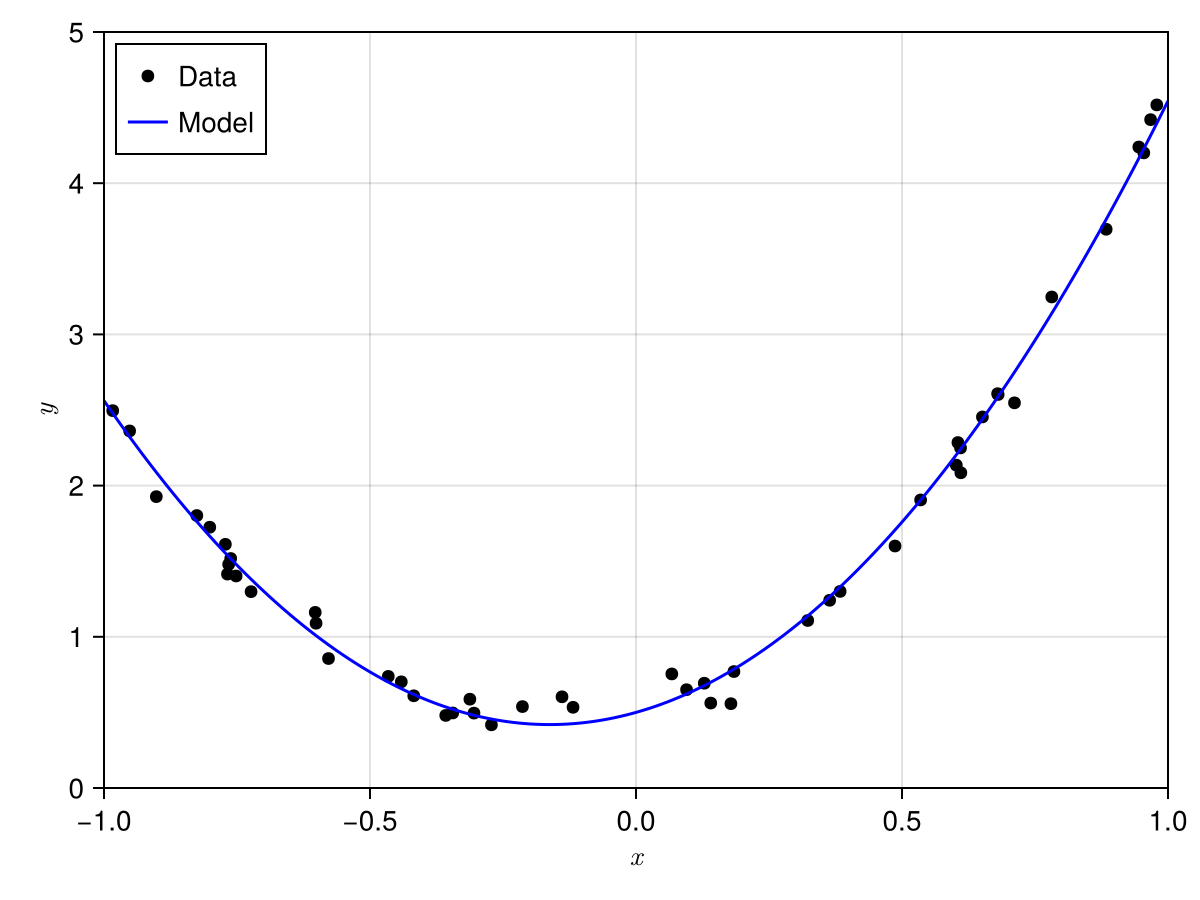

In [8]:
fig = Figure()
xplot=-1:0.01:1
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",limits=(-1,1,0,5))
scatter!(ax,x_samples,y_samples;label="Data",color=:black)
lines!(ax,xplot,fmodel(a,xplot);label="Model",color=:blue)
axislegend(ax;position = :lt)
fig

---
**Class Demo 01:** Generate a fictitious data set from the function

$
y=2x^2-10x+3+\epsilon
$

and use 

$f_{model}(x)=a_0+a_1 x+a_2 x^2$

$\epsilon$ is a small amount of random noise. Can you find a set of $a_0$, $a_1$ and $a_2$  that make $f_{model}(x)$ looks like $y_i$?  Use the domain $x\in[0,2\pi]$.  Here, find $a_0$, $a_1$ and $a_2$  using the "Normal equations" method.  

---

**Another way of thinking about  the method of  linear least squares**

Suppose you are asked to fit a model to some data, $(x_i,y_i)$.  For illustrative purposes, I will assume a model of the form 

$f_{model}(x)=a_0+a_1x+a_2x^2$.

If we have 5 data points, what we would like to do is to find

$a_0$, $a_1$ and $a_2$ such that 

\begin{bmatrix}
1 & x_1 & x_1^2\\
1 & x_2 & x_2^2\\
1 & x_3 & x_3^2\\
1 & x_4 & x_4^2\\
1 & x_5 & x_5^2\\
\end{bmatrix}\begin{Bmatrix} a_0\\a_1\\a_2\end{Bmatrix}\approx\begin{Bmatrix}y_1\\y_2\\y_3\\y_4\\y_5\end{Bmatrix}

Usually we cannot solve this equation because we have more equations
than unknowns (5 equations but only 3 ( ￼ and ￼) unknowns. However, the Normal equation tells us that to get the best possible  values of
$a_0$, $a_1$ and $a_2$￼ and ￼ that satisfies this equation, we need
to solve 

$$
\begin{bmatrix}
1 & 1 & 1 & 1& 1\\
x_1 & x_2 & x_3 & x_4 & x_5\\
x_1^2 & x_2^2 & x_3^2 & x_4^2 & x_5^2\\
\end{bmatrix}\begin{bmatrix}
1 & x_1 & x_1^2\\
1 & x_2 & x_2^2\\
1 & x_3 & x_3^2\\
1 & x_4 & x_4^2\\
1 & x_5 & x_5^2\\
\end{bmatrix}\begin{Bmatrix}
   {a_0 }  \\
   {a_1 }  \\
   {a_2 }  \\
\end{Bmatrix}=\begin{bmatrix}
1 & 1 & 1 & 1& 1\\
x_1 & x_2 & x_3 & x_4 & x_5\\
x_1^2 & x_2^2 & x_3^2 & x_4^2 & x_5^2\\
\end{bmatrix}\begin{Bmatrix}
   {y_1 }  \\
   {y_2 }  \\   
   {y_3 }  \\
  {y_4 }  \\
  {y_5 }  \\
\end{Bmatrix}
$$


or  $[V]^{T}[V]\vec{a}=[V]^{T}\vec{y}$

where 
$
V=\begin{bmatrix}
1 & x_1 & x_1^2\\
1 & x_2 & x_2^2\\
1 & x_3 & x_3^2\\
1 & x_4 & x_4^2\\
1 & x_5 & x_5^2\\
\end{bmatrix}
$

---
**Class Demo 02:** Read the data from the file "Data.csv" and try to see if you can get a good fit with a third order polynomial

---


Prepared by Andrew Ooi 9th July 2026